## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [4]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_2023-May-2nd_filled.csv', encoding=enc)

In [5]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean_new,lst_jan_night_mean_new,lst_feb_day_mean_new,lst_feb_night_mean_new,lst_mar_day_mean_new,lst_mar_night_mean_new,lst_apr_day_mean_new,lst_apr_night_mean_new,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan_new,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week_new,acc_rainfall_2week_new
0,abano terme,veneto,11.79539,45.35783,2023-05-16,2023,5,2023-05-13,45.358184,11.797125,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,2023-05-16,45.358184,11.797125,14793.0,14140.0,45.358184,11.797125,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,2023-05-16,45.350207,11.750054,248.764906,2023-05-09,2023-05-02,2023-05-09,2023-05-02,70.863885,89.657674
1,adria,veneto,12.03247,45.07647,2023-05-16,2023,5,2023-05-13,45.075215,12.030687,0.663630,0.398058,-0.596588,-0.398058,0.186254,0.098625,-0.137048,-0.098625,0.000000,0.000000,0.000000,0.000000,2023-05-16,45.075215,12.030687,14939.0,13861.0,45.075215,12.030687,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,2023-05-16,45.050206,12.050055,443.337031,2023-05-09,2023-05-02,2023-05-09,2023-05-02,79.000943,86.508775
2,adria,veneto,12.05787,45.05851,2023-05-16,2023,5,2023-05-13,45.057249,12.057637,0.172279,-0.082630,-0.196530,0.082630,0.272312,0.014919,-0.282289,-0.014919,0.098724,0.146178,0.079921,0.146178,2023-05-16,45.057249,12.057637,15072.0,13873.0,45.057249,12.057637,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,2023-05-16,45.050206,12.050055,443.337031,2023-05-09,2023-05-02,2023-05-09,2023-05-02,79.000943,86.508775
3,adria,veneto,12.05787,45.07647,2023-05-16,2023,5,2023-05-13,45.075215,12.057637,0.607957,0.338719,-0.539605,-0.338719,0.423923,0.196162,-0.413077,-0.196162,0.173547,0.153933,0.124206,0.153933,2023-05-16,45.075215,12.057637,14882.0,13791.0,45.075215,12.057637,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,2023-05-16,45.050206,12.050055,443.337031,2023-05-09,2023-05-02,2023-05-09,2023-05-02,79.000943,86.508775
4,affi,veneto,10.77673,45.55680,2023-05-16,2023,5,2023-05-13,45.555814,10.777538,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,2023-05-16,45.555814,10.777538,14715.0,14218.0,45.555814,10.777538,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,2023-05-16,45.550208,10.750049,102.643676,2023-05-09,2023-05-02,2023-05-09,2023-05-02,32.024413,44.276372


In [6]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [7]:
cols = dataset.columns
cols

Index(['lau1', 'nuts2', 'x', 'y', 'dt_placement', 'year', 'month',
       'indices_image_date', 'indices_lat', 'indices_lon', 'ndvi_new',
       'ndmi_new', 'ndwi_new', 'ndbi_new', 'ndvi_mean_new', 'ndmi_mean_new',
       'ndwi_mean_new', 'ndbi_mean_new', 'ndvi_std_new', 'ndmi_std_new',
       'ndwi_std_new', 'ndbi_std_new', 'lst_image_date', 'lst_lat', 'lst_lon',
       'lst_day_new', 'lst_night_new', 'monthly_lst_lat', 'monthly_lst_lon',
       'lst_jan_day_mean_new', 'lst_jan_night_mean_new',
       'lst_feb_day_mean_new', 'lst_feb_night_mean_new',
       'lst_mar_day_mean_new', 'lst_mar_night_mean_new',
       'lst_apr_day_mean_new', 'lst_apr_night_mean_new',
       'indices_image_date.1', 'indices_lat.1', 'indices_lon.1',
       'acc_rainfall_jan_new', 'dt_placement_minus_7', 'dt_placement_minus_14',
       'dt_placement_minus_7_avail', 'dt_placement_minus_14_avail',
       'acc_rainfall_1week_new', 'acc_rainfall_2week_new'],
      dtype='object')

In [8]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [9]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,abano terme,veneto,11.79539,45.35783,2023-05-16,2023,5,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.0,14140.0,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674
1,adria,veneto,12.03247,45.07647,2023-05-16,2023,5,0.663630,0.398058,-0.596588,-0.398058,0.186254,0.098625,-0.137048,-0.098625,0.000000,0.000000,0.000000,0.000000,14939.0,13861.0,13924.375000,13752.800000,14071.181818,13559.142857,14506.750000,13868.692308,14745.500000,13934.300000,443.337031,79.000943,86.508775
2,adria,veneto,12.05787,45.05851,2023-05-16,2023,5,0.172279,-0.082630,-0.196530,0.082630,0.272312,0.014919,-0.282289,-0.014919,0.098724,0.146178,0.079921,0.146178,15072.0,13873.0,14018.166667,13711.800000,14072.000000,13638.083333,14510.727273,13940.769231,14732.461538,13989.000000,443.337031,79.000943,86.508775
3,adria,veneto,12.05787,45.07647,2023-05-16,2023,5,0.607957,0.338719,-0.539605,-0.338719,0.423923,0.196162,-0.413077,-0.196162,0.173547,0.153933,0.124206,0.153933,14882.0,13791.0,13942.000000,13738.333333,14045.700000,13574.000000,14485.454545,13886.923077,14697.000000,13907.700000,443.337031,79.000943,86.508775
4,affi,veneto,10.77673,45.55680,2023-05-16,2023,5,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.0,14218.0,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-05-16,abano terme,veneto,11.795390,45.357830,2023.0,5.0,0.305836,0.195181,-0.211233,-0.195181,0.451248,0.214649,-0.369369,-0.214649,0.138496,0.084394,0.116102,0.084394,14793.000000,14140.000000,14036.375000,13697.666667,14061.500000,13617.923077,14574.769231,13982.000000,14732.538462,14005.000000,248.764906,70.863885,89.657674
1,2023-05-16,adria,veneto,12.049403,45.070483,2023.0,5.0,0.481289,0.218049,-0.444241,-0.218049,0.294163,0.103235,-0.277471,-0.103235,0.090757,0.100037,0.068042,0.100037,14964.333333,13841.666667,13961.513889,13734.311111,14062.960606,13590.408730,14500.977273,13898.794872,14724.987179,13943.666667,443.337031,79.000943,86.508775
2,2023-05-16,affi,veneto,10.776730,45.556800,2023.0,5.0,0.215253,0.343317,-0.097417,-0.343317,0.286031,0.303942,-0.179514,-0.303942,0.070778,0.039374,0.082097,0.039374,14715.000000,14218.000000,13972.222222,13697.857143,14089.076923,13693.533333,14516.500000,13870.071429,14575.470588,14001.444444,102.643676,32.024413,44.276372
3,2023-05-16,agna,veneto,11.965390,45.175310,2023.0,5.0,0.285199,-0.009342,-0.308480,0.009342,0.363783,0.092128,-0.365535,-0.092128,0.087480,0.080303,0.066134,0.080303,14835.000000,14251.000000,13874.500000,13686.750000,14045.111111,13555.769231,14457.333333,13878.888889,14720.230769,13913.461538,402.548818,82.096243,96.321740
4,2023-05-16,agordo,veneto,12.059120,46.313990,2023.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2023-05-16,zevio,veneto,11.127335,45.353970,2023.0,5.0,0.557068,0.281638,-0.474726,-0.281638,0.526192,0.279376,-0.447319,-0.279376,0.067586,0.054155,0.060909,0.054155,14804.000000,14281.500000,13976.444444,13611.633929,14099.275000,13581.468750,14606.142857,13901.145455,14722.108333,13993.187500,134.635950,56.221731,64.747591
567,2023-05-16,zimella,veneto,11.358050,45.347770,2023.0,5.0,0.238728,0.188525,-0.200552,-0.188525,0.329670,0.225247,-0.288365,-0.225247,0.126394,0.078268,0.104741,0.078268,14817.000000,14136.000000,13930.500000,13658.500000,14134.750000,13579.470588,14627.352941,13914.700000,14812.846154,13957.700000,166.673608,55.920659,63.511989
568,2023-05-16,zoppe da cadore,veneto,12.178780,46.388350,2023.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000
569,2023-05-16,zovencedo,veneto,11.494300,45.437980,2023.0,5.0,0.494438,0.399115,-0.380781,-0.399115,0.494438,0.399115,-0.380781,-0.399115,0.000000,0.000000,0.000000,0.000000,14627.000000,14174.000000,13943.416667,13727.714286,14065.416667,13746.400000,14413.875000,13990.727273,14519.125000,13987.400000,156.308827,48.271029,68.225934


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

<AxesSubplot:>

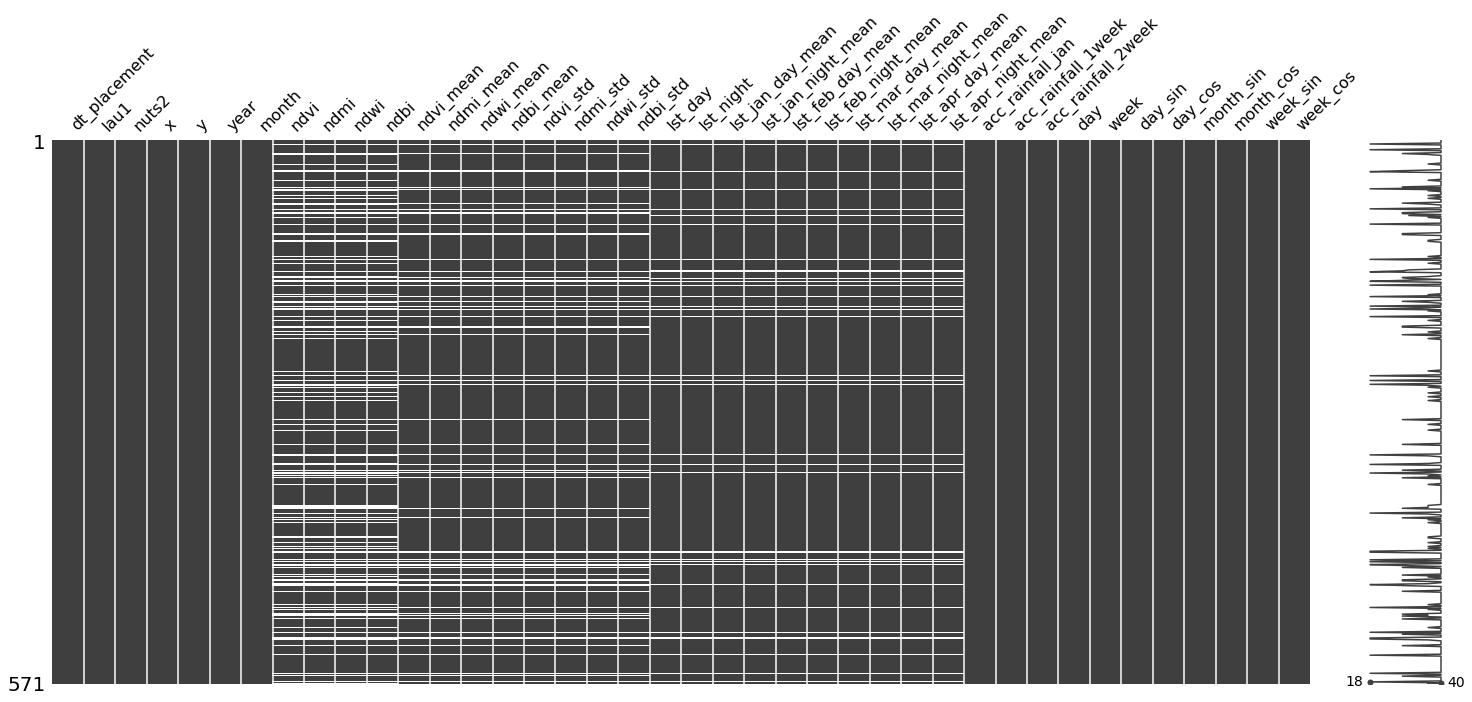

In [15]:
missingno.matrix(dataset)

In [16]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2010-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [17]:
mosquito_data.nuts2.unique()

array(['Veneto', 'Lombardia', 'Firuli-Venezia-Giulia',
       'Friuli-Venezia-Giulia'], dtype=object)

In [18]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'Veneto'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [19]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'wc_mean_dist_1000', 'coast_mean_dist_1000',
       'dem_mean_1km', 'slope_mean_1km', 'aspect_mean_1km', 'waw_mean_1km',
       'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [20]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

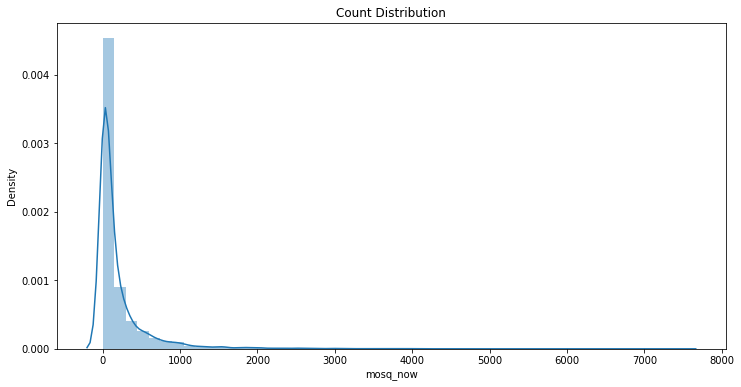

In [21]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [22]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

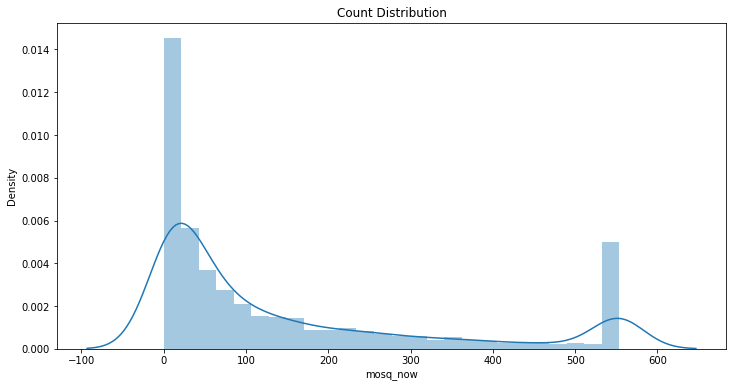

In [23]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

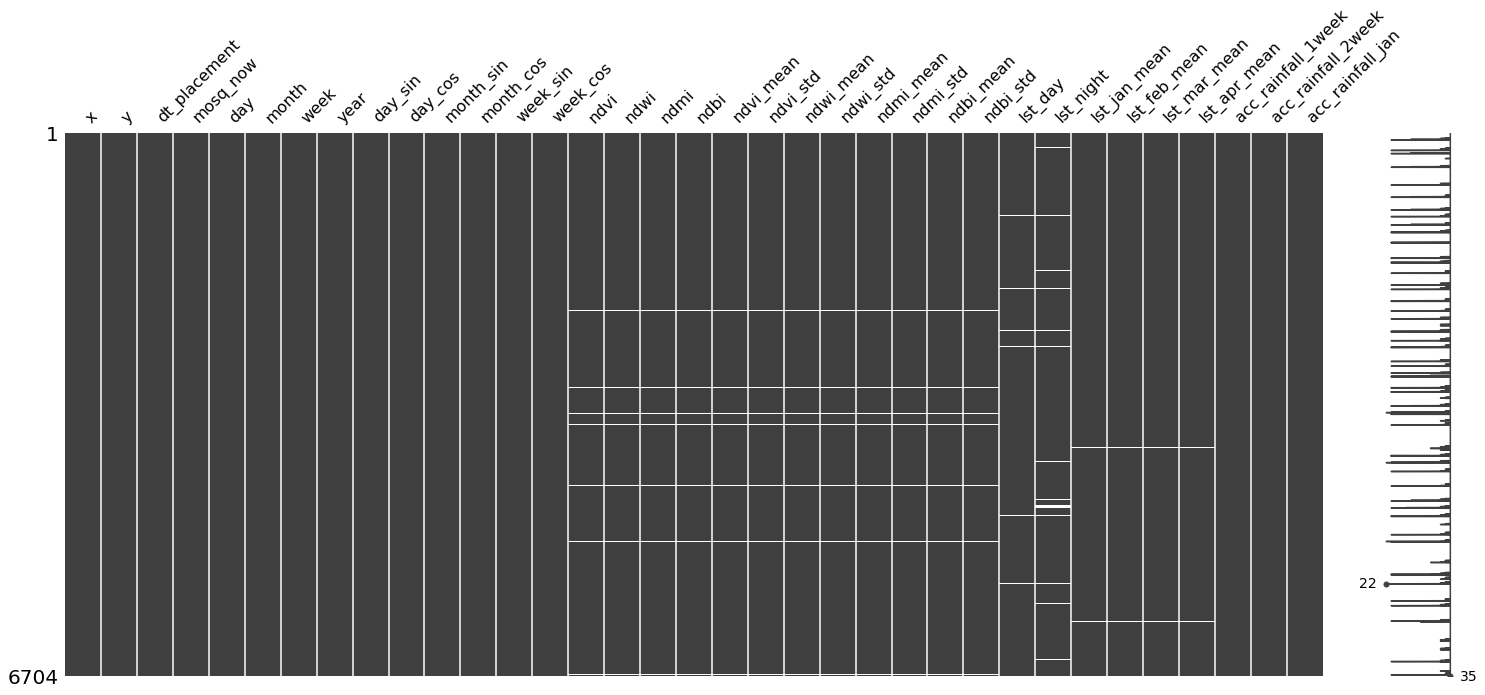

In [24]:
missingno.matrix(mosquito_data_nuts2)

In [25]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [26]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

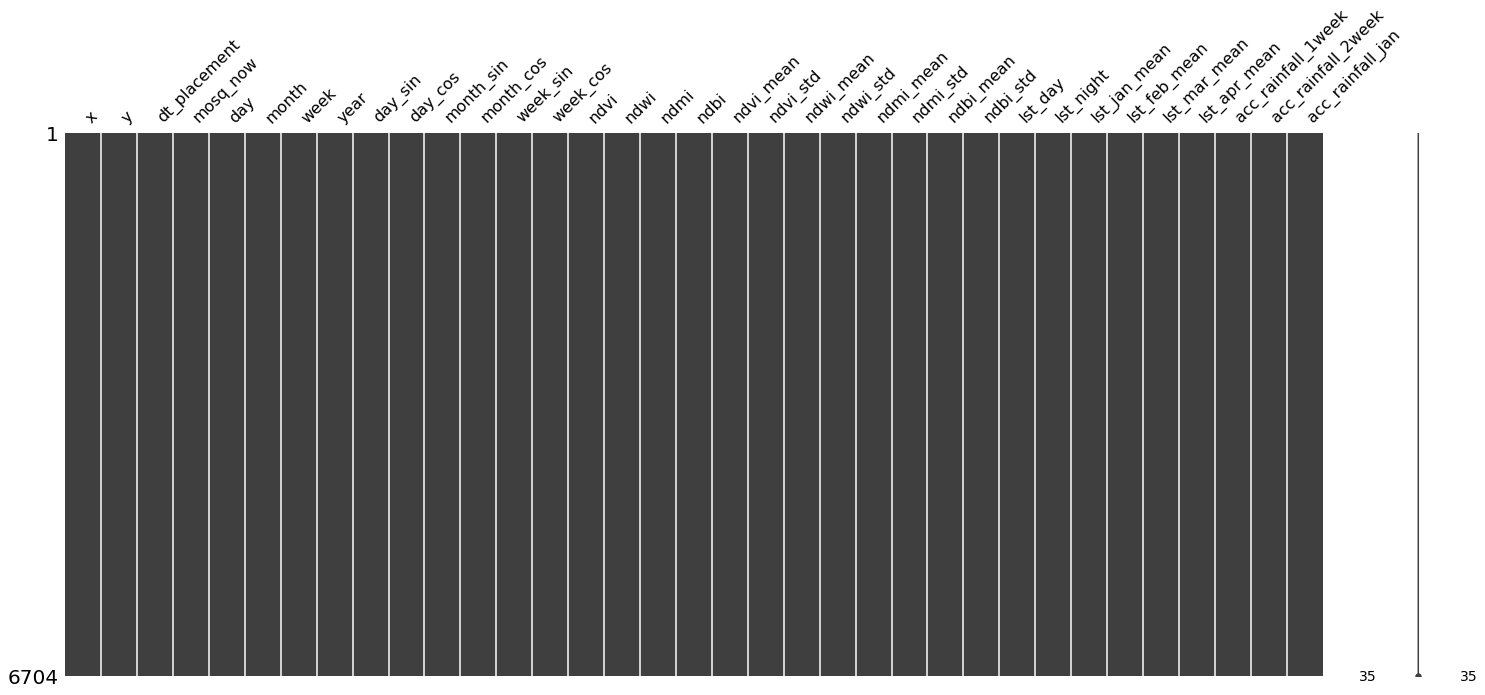

In [27]:
missingno.matrix(mosquito_data_nuts2)

In [28]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [29]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   61.  553.7]


In [30]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 6.71436 | Val Loss: 4.71057 | Train Acc: 1.814| Val Acc: 1.277
Epoch 002: | Train Loss: 5.95468 | Val Loss: 4.60705 | Train Acc: 1.647| Val Acc: 1.252
Epoch 003: | Train Loss: 5.67047 | Val Loss: 4.38741 | Train Acc: 1.585| Val Acc: 1.219
Epoch 004: | Train Loss: 5.34343 | Val Loss: 4.42818 | Train Acc: 1.500| Val Acc: 1.227
Epoch 005: | Train Loss: 5.06229 | Val Loss: 4.31894 | Train Acc: 1.449| Val Acc: 1.189
Epoch 006: | Train Loss: 5.06472 | Val Loss: 4.29639 | Train Acc: 1.455| Val Acc: 1.203
Epoch 007: | Train Loss: 4.84285 | Val Loss: 4.27142 | Train Acc: 1.400| Val Acc: 1.189
Epoch 008: | Train Loss: 4.73089 | Val Loss: 4.27188 | Train Acc: 1.386| Val Acc: 1.179
Epoch 009: | Train Loss: 4.69046 | Val Loss: 4.21923 | Train Acc: 1.375| Val Acc: 1.169
Epoch 010: | Train Loss: 4.62691 | Val Loss: 4.38913 | Train Acc: 1.351| Val Acc: 1.224
Epoch 011: | Train Loss: 4.53022 | Val Loss: 4.25064 | Train Acc: 1.326| Val Acc: 1.204
Epoch 012: | Train Loss: 4.44521

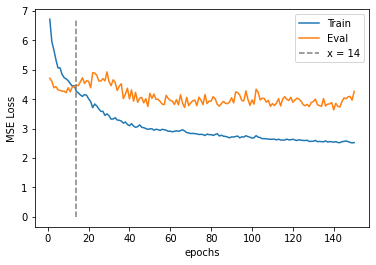

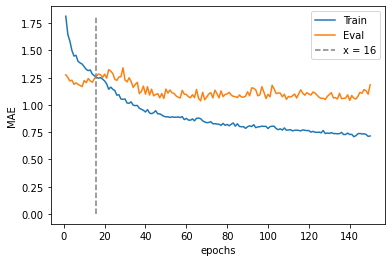

In [31]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [32]:
metrics(train, test, threshold=30)

MAE on train set:  94.79896131349052
min prediction: 1
max prediction: 1027

MAE on test set:  109.84812735468161
Error ⩽ 30: 27.24 %
min prediction: 1
max prediction: 891


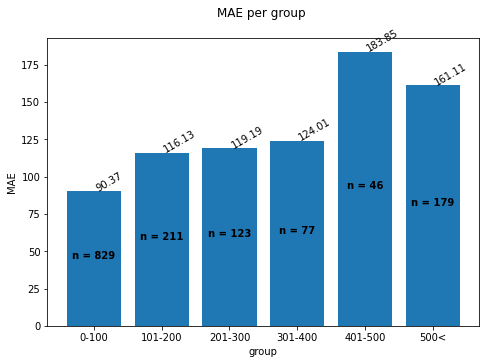

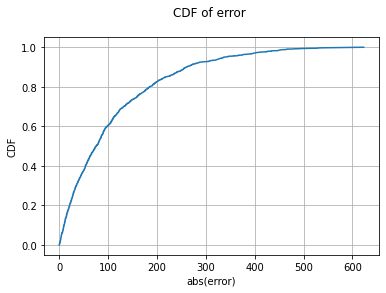

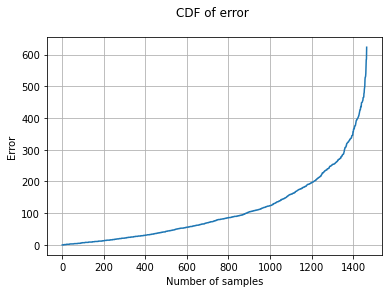

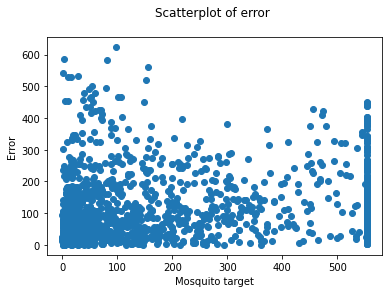

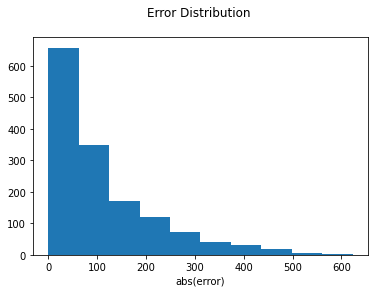

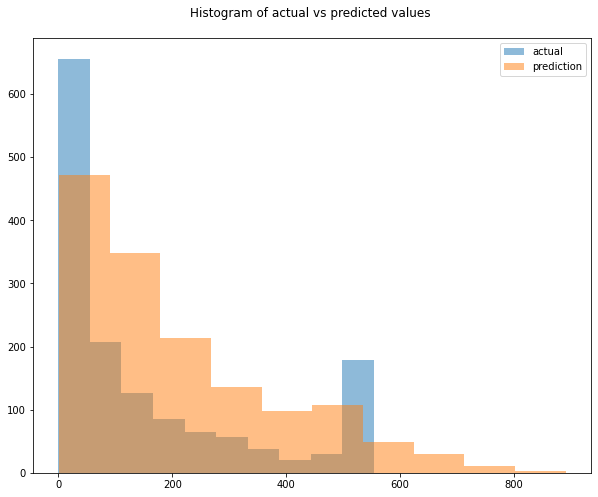

In [33]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 2.91299 | Val Loss: 0.36156 | Train Acc: 0.889| Val Acc: 0.394
Epoch 002: | Train Loss: 2.77755 | Val Loss: 0.03028 | Train Acc: 0.858| Val Acc: 0.394
Epoch 003: | Train Loss: 2.71435 | Val Loss: 0.30674 | Train Acc: 0.837| Val Acc: 0.394
Epoch 004: | Train Loss: 2.70620 | Val Loss: 0.20160 | Train Acc: 0.842| Val Acc: 0.394
Epoch 005: | Train Loss: 2.67864 | Val Loss: 0.56715 | Train Acc: 0.824| Val Acc: 0.394
Epoch 006: | Train Loss: 2.67330 | Val Loss: 0.68006 | Train Acc: 0.832| Val Acc: 0.394
Epoch 007: | Train Loss: 2.66063 | Val Loss: 0.26683 | Train Acc: 0.834| Val Acc: 0.394
Epoch 008: | Train Loss: 2.63985 | Val Loss: 0.89384 | Train Acc: 0.824| Val Acc: 1.394
Epoch 009: | Train Loss: 2.66000 | Val Loss: 0.63257 | Train Acc: 0.823| Val Acc: 0.394
Epoch 010: | Train Loss: 2.60932 | Val Loss: 0.71518 | Train Acc: 0.816| Val Acc: 0.394
Epoch 011: | Train Loss: 2.66517 | Val Loss: 0.55495 | Train Acc: 0.831| Val Acc: 0.394
Epoch 012: | Train Loss: 2.59770

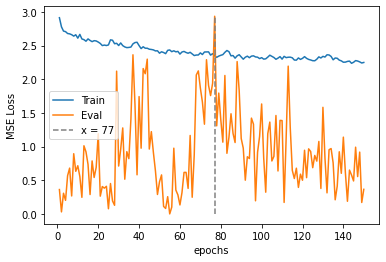

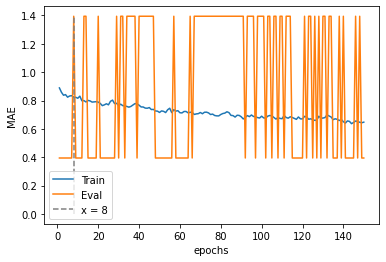

In [34]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [35]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [36]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [37]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [38]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [39]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [40]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

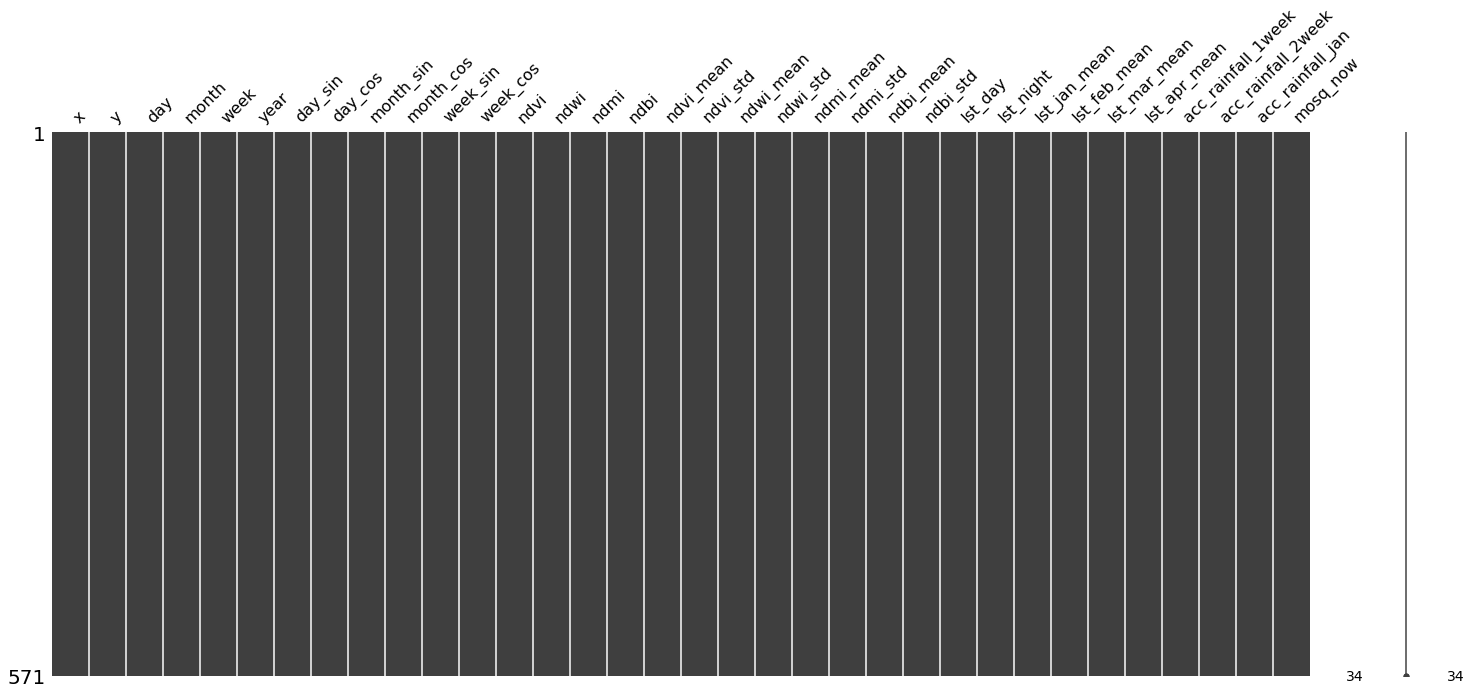

In [41]:
missingno.matrix(dataset_mamoth)

In [42]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [43]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [44]:
predictions = give_predictions(model, dataset_mamoth)

In [45]:
mosqutio_predictions['mosq_pred'] = predictions

In [46]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,11.795390,45.357830,2023-05-16,131
1,12.049403,45.070483,2023-05-16,203
2,10.776730,45.556800,2023-05-16,58
3,11.965390,45.175310,2023-05-16,90
4,12.059120,46.313990,2023-05-16,37
...,...,...,...,...
566,11.127335,45.353970,2023-05-16,123
567,11.358050,45.347770,2023-05-16,202
568,12.178780,46.388350,2023-05-16,32
569,11.494300,45.437980,2023-05-16,173


In [47]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2023-May-2nd.csv', index = False)